In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

## Journal wants a sans serif font
matplotlib.rcParams['font.sans-serif'] = "Arial"
matplotlib.rcParams['font.family'] = "sans-serif"
sns.axes_style({'font.family': ['sans-serif'],
                'font.sans-serif':['Arial']
               })

## Make exported plots' text seen as text in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sns.set_style("white")
sns.set_style("ticks")


In [2]:
df = pd.read_csv("z-position-z-slices.csv")
df.head()

,Label,img,Centroid.X_MAPPER,Centroid.Y_MAPPER,Centroid.Z_MAPPER,nSlices,Total_Height
0,1,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,18.789,27.486,2.370,25,11.25
1,2,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,54.449,67.518,0.044,25,11.25
2,3,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2.469,82.874,5.612,25,11.25
3,4,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,5.271,87.041,1.677,25,11.25
4,5,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,35.624,0.198,0.687,25,11.25


In [3]:
# Adds additional columns to the df you already created
df['Name'] = df['img'].str.replace('_Simple Segmentation_lbl-sizeFilt$', '', regex=True)
df['Replicate'] = df['Name'].str.extract(r'_R(\d+)$')[0] # Extract the integer after "_R"
df['Image_number'] = df['img'].str.extract(r'_(\d{3})_R')[0]  # Extract three digits before _R
df['Cell_Type'] = df['img'].str.split('+').str[0]  # Extract the first part before '+'

df['Normalized_z-position'] = df['Centroid.Z_MAPPER'] / df['Total_Height']
df['Basal'] = df['Centroid.Z_MAPPER'] <= 0.9
df.to_csv("pretty-dataset.csv",index=False) #Creates a CSV file with the additional columns or data you created

df.head()


,Label,img,Centroid.X_MAPPER,Centroid.Y_MAPPER,Centroid.Z_MAPPER,nSlices,Total_Height,Name,Replicate,Image_number,Cell_Type,Normalized_z-position,Basal
0,1,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,18.789,27.486,2.370,25,11.25,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,001,A431,0.210667,False
1,2,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,54.449,67.518,0.044,25,11.25,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,001,A431,0.003911,True
2,3,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2.469,82.874,5.612,25,11.25,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,001,A431,0.498844,False
3,4,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,5.271,87.041,1.677,25,11.25,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,001,A431,0.149067,False
4,5,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,35.624,0.198,0.687,25,11.25,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,001,A431,0.061067,True


In [4]:
heights_df = df.groupby(['Cell_Type', 'Name', 'Replicate'])['Total_Height'].unique().to_frame().reset_index()
heights_df

,Cell_Type,Name,Replicate,Total_Height
0,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[11.25]
1,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[10.35]
2,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[13.5]
3,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[15.75]
4,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[13.05]
5,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[12.6]
6,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[11.7]
7,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[12.15]
8,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[10.35]
9,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[9.9]


In [5]:
heights_df['image_height'] = heights_df['Total_Height'].apply(lambda x: x[0])
heights_df.to_csv("image_heights.csv",index=False)
heights_df


,Cell_Type,Name,Replicate,Total_Height,image_height
0,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[11.25],11.25
1,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[10.35],10.35
2,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[13.5],13.50
3,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[15.75],15.75
4,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[13.05],13.05
5,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[12.6],12.60
6,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[11.7],11.70
7,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,2,[12.15],12.15
8,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,3,[10.35],10.35
9,A431,A431+ER-StayGold+MAPPER-mApple_MAPPER+ER+WGA_0...,1,[9.9],9.90


Welch's t-test results: t=-5.2540, p=0.0000


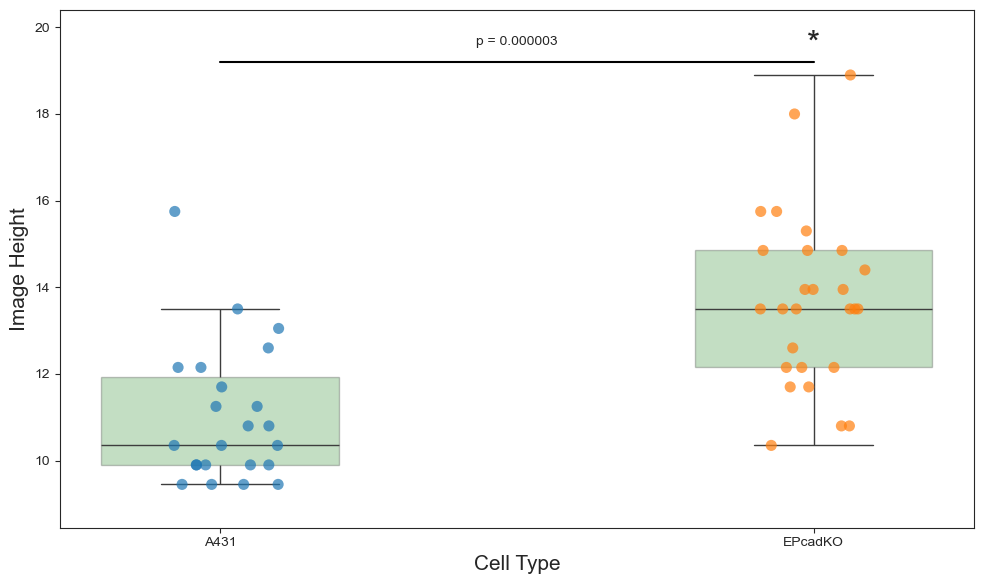

In [6]:
# Create the figure
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Create the dotplot 
ax = sns.stripplot(x='Cell_Type', y='image_height', data=heights_df, hue="Cell_Type", 
                  jitter=True, size=8, alpha=0.7)

# Add a boxplot to show distribution statistics
sns.boxplot(x='Cell_Type', y='image_height', data=heights_df,
           width=0.4, boxprops=dict(alpha=.3),
           showfliers=False)

# Get data for each group for statistical testing
a431_heights = heights_df[heights_df['Cell_Type'] == 'A431']['image_height']
epcadko_heights = heights_df[heights_df['Cell_Type'] == 'EPcadKO']['image_height']

# Perform Welch's t-test (unpaired, two-sided, unequal variances)
t_stat, p_value = stats.ttest_ind(a431_heights, epcadko_heights, equal_var=False)

# Calculate maximum height for annotation placement
max_height = heights_df['image_height'].max()

# Add asterisk for significance if p < 0.05
if p_value < 0.05:
    plt.text(1, max_height + 0.5, '*', fontsize=24, ha='center')
    
    # Add horizontal line for the significance bar
    plt.plot([0, 1], [max_height + 0.3, max_height + 0.3], color='black', linewidth=1.5)
    
    # Add p-value text
    plt.text(0.5, max_height + 0.7, f'p = {p_value:.6f}', ha='center')

# Add labels and title
#plt.title('Image Heights by Cell Type', fontsize=16)
plt.xlabel('Cell Type', fontsize=15)
plt.ylabel('Image Height', fontsize=15)

 # Set global X tick label font size
sns.set(rc={'xtick.labelsize': 12})
sns.set(rc={'ytick.labelsize': 12})

# Show axis ticks
plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)

# Adjust y-axis limits to accommodate annotations
plt.ylim(heights_df['image_height'].min() - 1, max_height + 1.5)

# Print statistical results (optional)
print(f"Welch's t-test results: t={t_stat:.4f}, p={p_value:.4f}")

# Show the plot
plt.tight_layout()
plt.show()

In [7]:
# Group by 'Replicate', 'Cell_Type', and 'basal' and calculate counts
summary_counts = df.groupby(['Replicate', 'Cell_Type', 'Basal']).size().reset_index(name='Count')
print(summary_counts)
summary_counts.to_csv("Basal-nonbasal-ERPMCS-count.csv",index=False)


   Replicate Cell_Type  Basal  Count
0          1      A431  False  19534
1          1      A431   True   8348
2          1   EPcadKO  False   7483
3          1   EPcadKO   True  19322
4          2      A431  False  11530
5          2      A431   True   6171
6          2   EPcadKO  False   7041
7          2   EPcadKO   True  11932
8          3      A431  False  10569
9          3      A431   True   5612
10         3   EPcadKO  False   3791
11         3   EPcadKO   True  11254


In [8]:
# Group by 'Cell_Type', 'Basal', and calculate counts
summary_counts = df.groupby(['Cell_Type', 'Basal']).size().reset_index(name='Count')
print(summary_counts)

  Cell_Type  Basal  Count
0      A431  False  41633
1      A431   True  20131
2   EPcadKO  False  18315
3   EPcadKO   True  42508


#### Similar results are seen throughout the replicates

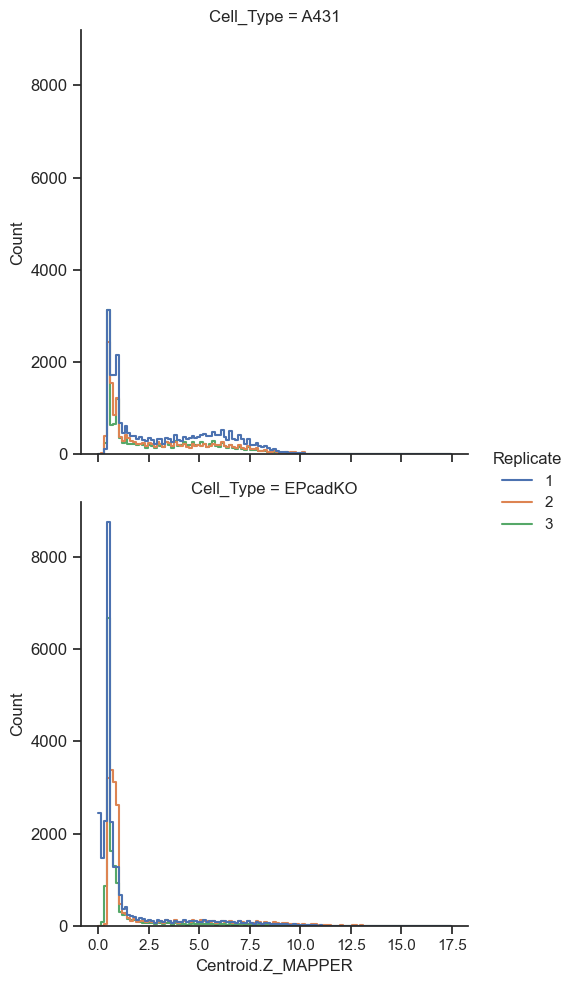

In [9]:
sns.set_style("white")
sns.set_style("ticks")
sns.displot(data = df, x = "Centroid.Z_MAPPER",
             hue="Replicate",
            row = "Cell_Type",
             stat="count",
             #common_norm=False,
             element="step",
             fill=False,
            )
#plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)


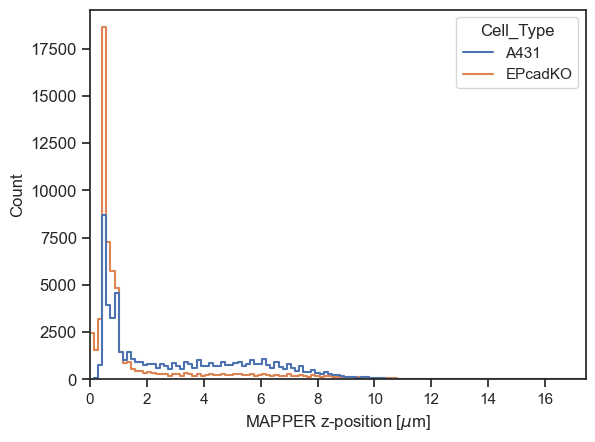

In [18]:
sns.set_style("white")
sns.set_style("ticks")

# MAPPER z-position by cell type
e = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="count",
             #common_norm=False,
             element="step",
             fill=False,
            )
e.set_xlim(0, max(df["Centroid.Z_MAPPER"]))

#plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)

e.set_xlabel(r"MAPPER z-position [$\mu$m]")
#plt.axvline( x = 0.9, color='black', label = "basal threshold")
plt.savefig("2025-05-15_Count_Z-position.png", dpi=600)
plt.savefig("2025-05-15_Count_Z-position.pdf", dpi=600,transparent=True)

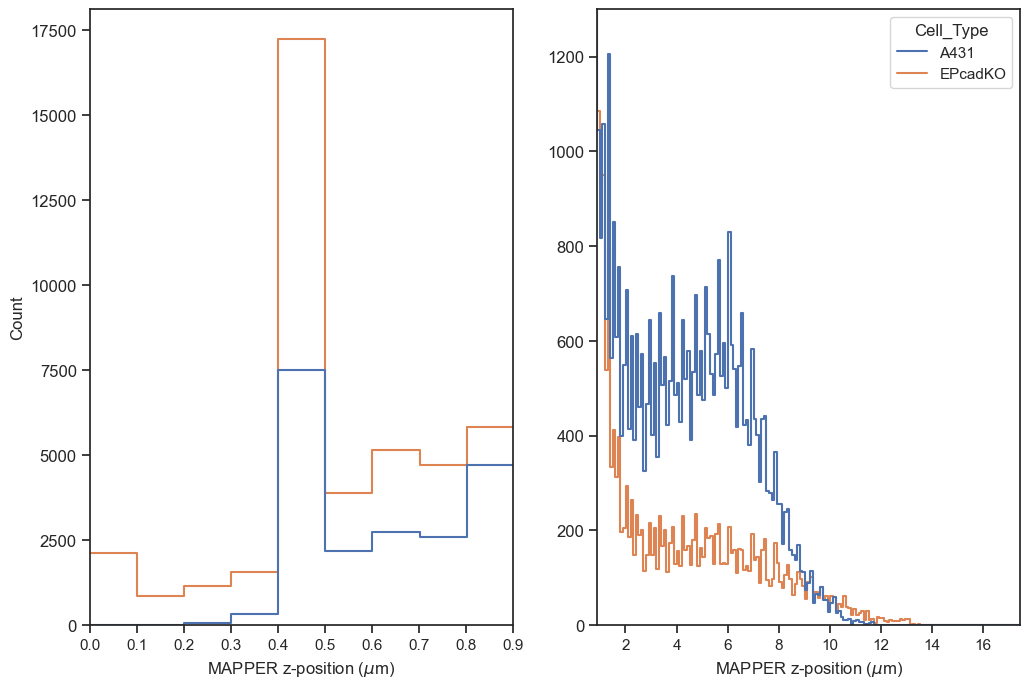

In [19]:
sns.set_style("white")
sns.set_style("ticks")


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 8))

#plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)

e = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="count",
                 binwidth=0.1,
             common_norm=False,
             element="step",
             fill=False,
                 legend=False,
                 ax=ax1
                 
            )

e.set_xlim(0, 0.9)
e.set_xlabel(r"MAPPER z-position ($\mu$m)")

f = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="count",
                 binwidth=0.1,
             common_norm=False,
             element="step",
             fill=False,
                 ax=ax2
            )
f.set_ylabel("")
f.set_ylim(0, 1300)
f.set_xlim(0.9, max(df["Centroid.Z_MAPPER"]))
f.set_xlabel(r"MAPPER z-position ($\mu$m)")

#plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)

plt.savefig("2025-05-15_Count-MAPPER_Z-position-split.png", dpi=600)
plt.savefig("2025-05-15_Count-MAPPER_Z-position-split.pdf", dpi=600,transparent=True )


Text(0.5, 0, 'MAPPER z-position ($\\mu$m)')

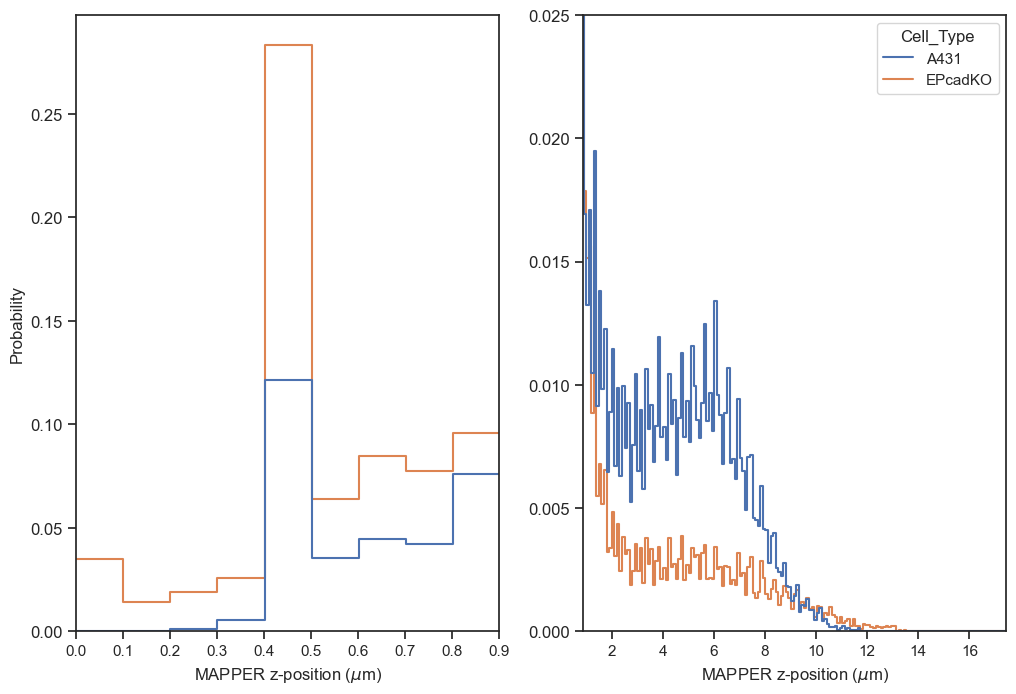

In [12]:
# Probability map with basal and non-basal MAPPER
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 8))
sns.set_style("white")

e = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="probability",
                 binwidth=0.1,
             common_norm=False,
             element="step",
             fill=False,
                 legend=False,
                 ax=ax1
                 
            )
e.set_xlim(0, 0.9)
e.set_xlabel(r"MAPPER z-position ($\mu$m)")
f = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="probability",
                 binwidth=0.1,
             common_norm=False,
             element="step",
             fill=False,
                 ax=ax2
            )
f.set_ylabel("")
f.set_ylim(0, 0.025)
f.set_xlim(0.9, max(df["Centroid.Z_MAPPER"]))
f.set_xlabel(r"MAPPER z-position ($\mu$m)")
#plt.savefig("2025-05-15_Probability_MAPPER-Z-position-split.png", dpi=600)

Text(0.5, 0, 'MAPPER z-position [$\\mu$m]')

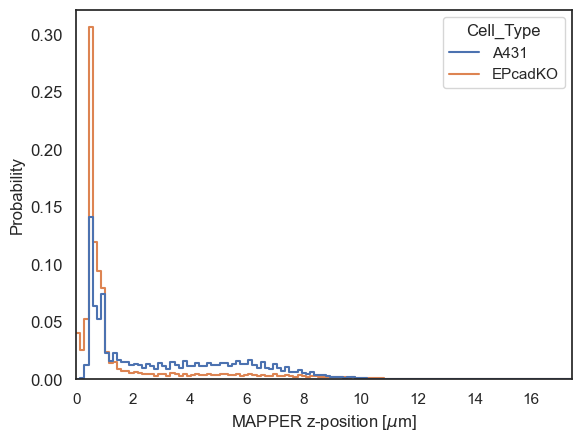

In [13]:
# Probability vs. MAPPER Z-position

e = sns.histplot(data = df, x = "Centroid.Z_MAPPER",
             hue="Cell_Type",
             stat="probability",
             common_norm=False,
             element="step",
             fill=False,
            )
e.set_xlim(0, max(df["Centroid.Z_MAPPER"]))
e.set_xlabel(r"MAPPER z-position [$\mu$m]")
#plt.axvline( x = 0.9, color='black', label = "basal threshold")
#plt.savefig("2025-05-15_Probability_MAPPER-Z-position.png", dpi=600)

Text(0.5, 0, 'Normalized MAPPER z-position')

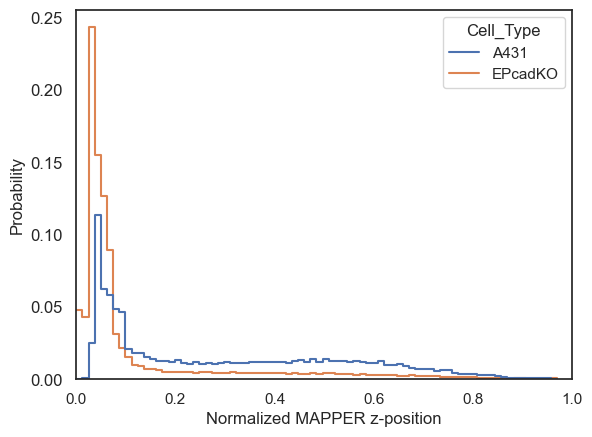

In [14]:
# Probability vs. Normalized MAPPER Z-position
sns.set_style("white")
e = sns.histplot(data = df, x = "Normalized_z-position",
             hue="Cell_Type",
             stat="probability",
             common_norm=False,
             element="step",
             fill=False,
            )
e.set_xlim(0, 1)
e.set_xlabel("Normalized MAPPER z-position")
#plt.savefig("2025-05-15_Probability_Normalized-Z-position.png", dpi=600)


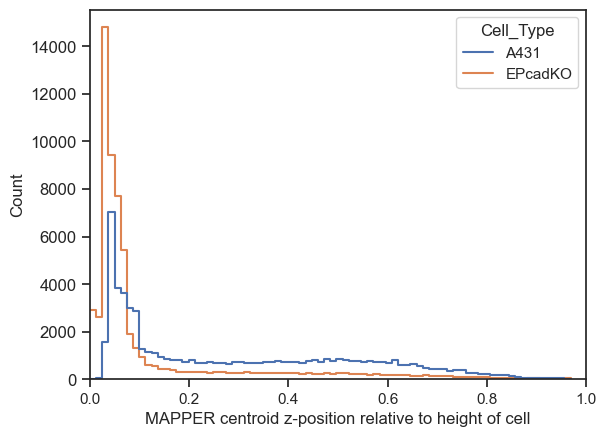

In [15]:
# Count vs. Normalized MAPPER z-position
sns.set_style("white")
e = sns.histplot(data = df, x = "Normalized_z-position",
             hue="Cell_Type",
             stat="count",
             common_norm=False,
             element="step",
             fill=False,
            )
e.set_xlim(0, 1)
e.set_xlabel(r"MAPPER centroid z-position relative to height of cell")
plt.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)



#plt.savefig("2025-05-15_Count_Normalized-Z-position.png", dpi=600)
plt.savefig("2025-05-15_Count_normalized-Z-position.pdf", dpi=600,transparent=True)